In [1]:
# ============================================
# FICHIER 3 : ÉVALUATION ET VISUALISATIONS
# 03_evaluation.ipynb
# ============================================

print("="*60)
print("FICHIER 3 : ÉVALUATION ET VISUALISATIONS AVANCÉES")
print("="*60)

# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import pickle

# Machine Learning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)



FICHIER 3 : ÉVALUATION ET VISUALISATIONS AVANCÉES


In [4]:
# ============================================
# SECTION 2 : CHARGEMENT DU MODÈLE ET DES DONNÉES
# ============================================


# Chargement du dataset
data_path = 'Data/cleaned_data.csv'
df = pd.read_csv(data_path)



# Séparation features/target
X = df.drop('generated_power_kw', axis=1)
y = df['generated_power_kw']

# Split train/test (même que dans le fichier 2)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Chargement du modèle


model_path = 'Models/best_model_xgboost.pkl'
with open(model_path, 'rb') as f:
    model = pickle.load(f)



# Chargement des métadonnées
metadata_path = 'Models/model_metadata.pkl'
with open(metadata_path, 'rb') as f:
    metadata = pickle.load(f)



# Affichage des informations du modèle
print("\n" + "="*60)
print("📋 INFORMATIONS DU MODÈLE")
print("="*60)
print(f"Nom              : {metadata['model_name']}")
print(f"Type             : {metadata['model_type']}")
print(f"Nombre features  : {metadata['n_features']}")
print(f"R² Test          : {metadata['performance']['r2_test']:.4f}")
print(f"MAE Test         : {metadata['performance']['mae_test']:.2f} kW")
print(f"RMSE Test        : {metadata['performance']['rmse_test']:.2f} kW")
print(f"Date création    : {metadata['date']}")

# Prédictions
print("\n" + "="*60)
print("🔮 GÉNÉRATION DES PRÉDICTIONS")
print("="*60)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Prédictions générées")
print(f"   Train : {len(y_train_pred)} prédictions")
print(f"   Test  : {len(y_test_pred)} prédictions")




📋 INFORMATIONS DU MODÈLE
Nom              : XGBoost Optimisé
Type             : XGBoost Regressor
Nombre features  : 20
R² Test          : 0.8172
MAE Test         : 263.74 kW
RMSE Test        : 408.66 kW
Date création    : 2026-02-14 17:53:07

🔮 GÉNÉRATION DES PRÉDICTIONS
Prédictions générées
   Train : 3370 prédictions
   Test  : 843 prédictions


In [5]:
# Calcul des métriques
print("\n" + "="*60)
print("MÉTRIQUES DE PERFORMANCE")
print("="*60)

# Train
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

print("\n🔹 TRAIN :")
print(f"   MAE  : {mae_train:.2f} kW")
print(f"   RMSE : {rmse_train:.2f} kW")
print(f"   R²   : {r2_train:.4f}")
print(f"   MAPE : {mape_train:.2f}%")

# Test
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print("\n🔹 TEST :")
print(f"   MAE  : {mae_test:.2f} kW")
print(f"   RMSE : {rmse_test:.2f} kW")
print(f"   R²   : {r2_test:.4f}")
print(f"   MAPE : {mape_test:.2f}%")

print("\n" + "="*60)
print("MODÈLE PRÊT POUR L'ÉVALUATION")
print("="*60)


MÉTRIQUES DE PERFORMANCE

🔹 TRAIN :
   MAE  : 41.99 kW
   RMSE : 59.91 kW
   R²   : 0.9959
   MAPE : 4302.18%

🔹 TEST :
   MAE  : 263.74 kW
   RMSE : 408.66 kW
   R²   : 0.8172
   MAPE : 15025.43%

MODÈLE PRÊT POUR L'ÉVALUATION


In [6]:
# ============================================
# SECTION 3 : VISUALISATIONS AVANCÉES
# ============================================

print("="*60)
print("VISUALISATIONS AVANCÉES DES PRÉDICTIONS")
print("="*60)

# Création d'un DataFrame pour l'analyse
results_df = pd.DataFrame({
    'Réel': y_test.values,
    'Prédit': y_test_pred,
    'Erreur': y_test.values - y_test_pred,
    'Erreur_Abs': np.abs(y_test.values - y_test_pred),
    'Erreur_Pct': np.abs((y_test.values - y_test_pred) / y_test.values) * 100
})

print("\nAperçu des résultats :")
print(results_df.head(10))

# Statistiques des erreurs
print("\n" + "="*60)
print("STATISTIQUES DES ERREURS")
print("="*60)
print(f"Erreur moyenne        : {results_df['Erreur'].mean():.2f} kW")
print(f"Erreur médiane        : {results_df['Erreur'].median():.2f} kW")
print(f"Erreur max (sur-est.) : {results_df['Erreur'].max():.2f} kW")
print(f"Erreur max (sous-est.): {results_df['Erreur'].min():.2f} kW")
print(f"Écart-type erreur     : {results_df['Erreur'].std():.2f} kW")



VISUALISATIONS AVANCÉES DES PRÉDICTIONS

Aperçu des résultats :
          Réel       Prédit      Erreur  Erreur_Abs    Erreur_Pct
0  2511.237500  2418.697266   92.540234   92.540234      3.685045
1   480.205120   302.054810  178.150310  178.150310     37.098794
2  2017.568700  1679.145386  338.423314  338.423314     16.773819
3   760.140120   586.975769  173.164351  173.164351     22.780583
4   220.395000    60.469410  159.925590  159.925590     72.563166
5    25.226724   204.153397 -178.926673  178.926673    709.274310
6     0.056667   -16.991472   17.048139   17.048139  30084.950843
7  2497.532800  2437.324951   60.207849   60.207849      2.410693
8   514.647220   525.782104  -11.134884   11.134884      2.163596
9   916.919160  1170.427856 -253.508696  253.508696     27.647879

STATISTIQUES DES ERREURS
Erreur moyenne        : -20.81 kW
Erreur médiane        : 4.41 kW
Erreur max (sur-est.) : 1404.94 kW
Erreur max (sous-est.): -2031.81 kW
Écart-type erreur     : 408.37 kW



Génération des graphiques


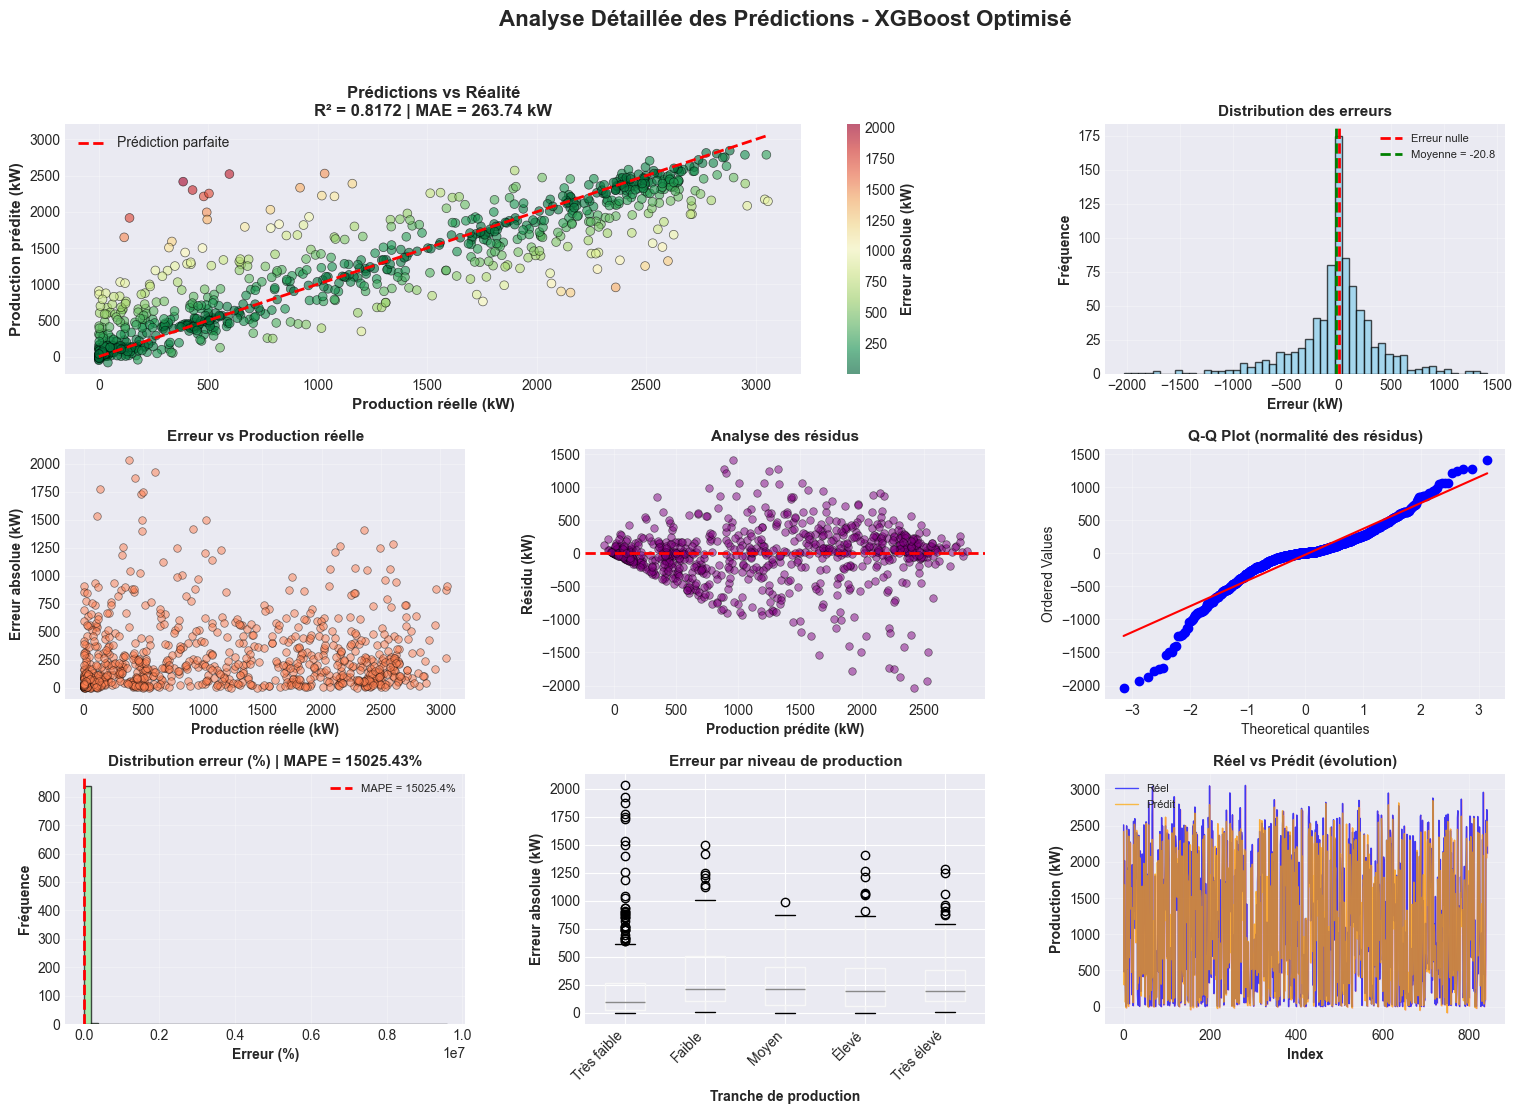

In [8]:
# Visualisations
print("\n" + "="*60)
print("Génération des graphiques")
print("="*60)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Graphique 1 : Prédictions vs Réalité (scatter plot détaillé)
ax1 = fig.add_subplot(gs[0, :2])
scatter = ax1.scatter(results_df['Réel'], results_df['Prédit'], 
                     c=results_df['Erreur_Abs'], cmap='RdYlGn_r', 
                     s=40, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.plot([results_df['Réel'].min(), results_df['Réel'].max()], 
         [results_df['Réel'].min(), results_df['Réel'].max()], 
         'r--', lw=2, label='Prédiction parfaite')
ax1.set_xlabel('Production réelle (kW)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Production prédite (kW)', fontweight='bold', fontsize=11)
ax1.set_title(f'Prédictions vs Réalité\nR² = {r2_test:.4f} | MAE = {mae_test:.2f} kW', 
              fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Erreur absolue (kW)', fontweight='bold')

# Graphique 2 : Distribution des erreurs
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(results_df['Erreur'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
ax2.axvline(x=results_df['Erreur'].mean(), color='green', linestyle='--', 
            linewidth=2, label=f'Moyenne = {results_df["Erreur"].mean():.1f}')
ax2.set_xlabel('Erreur (kW)', fontweight='bold', fontsize=10)
ax2.set_ylabel('Fréquence', fontweight='bold', fontsize=10)
ax2.set_title('Distribution des erreurs', fontweight='bold', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Graphique 3 : Erreur absolue en fonction de la production réelle
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(results_df['Réel'], results_df['Erreur_Abs'], 
           alpha=0.5, s=30, color='coral', edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Production réelle (kW)', fontweight='bold', fontsize=10)
ax3.set_ylabel('Erreur absolue (kW)', fontweight='bold', fontsize=10)
ax3.set_title('Erreur vs Production réelle', fontweight='bold', fontsize=11)
ax3.grid(True, alpha=0.3)

# Graphique 4 : Résidus (erreur vs prédit)
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(results_df['Prédit'], results_df['Erreur'], 
           alpha=0.5, s=30, color='purple', edgecolors='black', linewidth=0.5)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Production prédite (kW)', fontweight='bold', fontsize=10)
ax4.set_ylabel('Résidu (kW)', fontweight='bold', fontsize=10)
ax4.set_title('Analyse des résidus', fontweight='bold', fontsize=11)
ax4.grid(True, alpha=0.3)

# Graphique 5 : Q-Q Plot (normalité des résidus)
ax5 = fig.add_subplot(gs[1, 2])
from scipy import stats
stats.probplot(results_df['Erreur'], dist="norm", plot=ax5)
ax5.set_title('Q-Q Plot (normalité des résidus)', fontweight='bold', fontsize=11)
ax5.grid(True, alpha=0.3)

# Graphique 6 : Erreur en pourcentage
ax6 = fig.add_subplot(gs[2, 0])
ax6.hist(results_df['Erreur_Pct'], bins=50, color='lightgreen', 
         edgecolor='black', alpha=0.7)
ax6.set_xlabel('Erreur (%)', fontweight='bold', fontsize=10)
ax6.set_ylabel('Fréquence', fontweight='bold', fontsize=10)
ax6.set_title(f'Distribution erreur (%) | MAPE = {mape_test:.2f}%', 
              fontweight='bold', fontsize=11)
ax6.axvline(x=mape_test, color='red', linestyle='--', linewidth=2, 
            label=f'MAPE = {mape_test:.1f}%')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# Graphique 7 : Boxplot des erreurs par tranches de production
ax7 = fig.add_subplot(gs[2, 1])
results_df['Tranche_Production'] = pd.cut(results_df['Réel'], 
                                          bins=5, 
                                          labels=['Très faible', 'Faible', 'Moyen', 'Élevé', 'Très élevé'])
results_df.boxplot(column='Erreur_Abs', by='Tranche_Production', ax=ax7)
ax7.set_xlabel('Tranche de production', fontweight='bold', fontsize=10)
ax7.set_ylabel('Erreur absolue (kW)', fontweight='bold', fontsize=10)
ax7.set_title('Erreur par niveau de production', fontweight='bold', fontsize=11)
plt.sca(ax7)
plt.xticks(rotation=45, ha='right')
ax7.get_figure().suptitle('')

# Graphique 8 : Évolution temporelle (index comme proxy du temps)
ax8 = fig.add_subplot(gs[2, 2])
indices = np.arange(len(y_test))
ax8.plot(indices, y_test.values, label='Réel', alpha=0.7, linewidth=1, color='blue')
ax8.plot(indices, y_test_pred, label='Prédit', alpha=0.7, linewidth=1, color='orange')
ax8.fill_between(indices, y_test.values, y_test_pred, alpha=0.2, color='red')
ax8.set_xlabel('Index', fontweight='bold', fontsize=10)
ax8.set_ylabel('Production (kW)', fontweight='bold', fontsize=10)
ax8.set_title('Réel vs Prédit (évolution)', fontweight='bold', fontsize=11)
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3)

plt.suptitle('Analyse Détaillée des Prédictions - XGBoost Optimisé', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('Outputs/10_detailed_predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



ANALYSE DES FEATURES IMPORTANTES

Top 15 Features les plus importantes :

                          Feature  Importance
               angle_of_incidence    0.152439
            total_cloud_cover_sfc    0.139856
           total_cloud_all_layers    0.117915
          total_precipitation_sfc    0.073442
                           zenith    0.058010
                       low_zenith    0.057876
                     total_precip    0.048145
      low_cloud_cover_low_cld_lay    0.040739
shortwave_radiation_backwards_sfc    0.039294
      mean_sea_level_pressure_MSL    0.034828
   medium_cloud_cover_mid_cld_lay    0.031495
  relative_humidity_2_m_above_gnd    0.029856
         wind_gust_10_m_above_gnd    0.029193
    high_cloud_cover_high_cld_lay    0.025460
        temperature_2_m_above_gnd    0.024674

Génération des graphiques d'importance


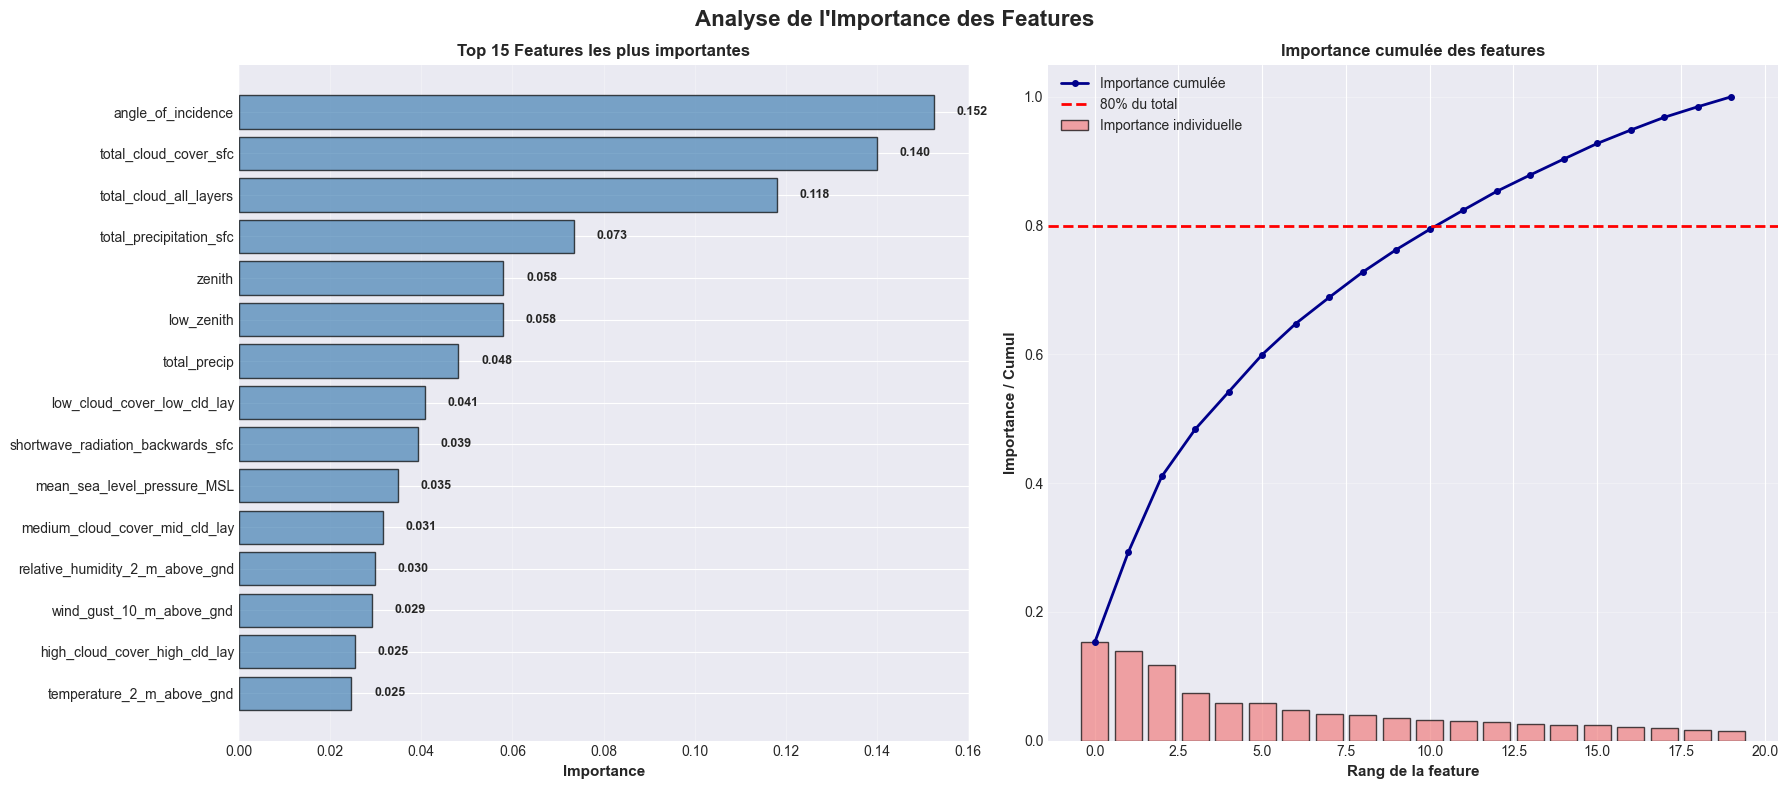

In [10]:
# ============================================
# SECTION 4 : ANALYSE DES FEATURES IMPORTANTES
# ============================================

print("="*60)
print("ANALYSE DES FEATURES IMPORTANTES")
print("="*60)

# Récupération de l'importance des features
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Features les plus importantes :\n")
print(feature_importance.head(15).to_string(index=False))

# Visualisation
print("\n" + "="*60)
print("Génération des graphiques d'importance")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Analyse de l\'Importance des Features', fontsize=16, fontweight='bold')

# Graphique 1 : Barplot horizontal (Top 15)
top_15 = feature_importance.head(15)
axes[0].barh(top_15['Feature'], top_15['Importance'], 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Importance', fontweight='bold', fontsize=11)
axes[0].set_title('Top 15 Features les plus importantes', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, v in enumerate(top_15['Importance']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)

# Graphique 2 : Importance cumulée
feature_importance_sorted = feature_importance.sort_values('Importance', ascending=False)
cumsum = feature_importance_sorted['Importance'].cumsum()

axes[1].bar(range(len(feature_importance_sorted)), feature_importance_sorted['Importance'], 
            color='lightcoral', edgecolor='black', alpha=0.7, label='Importance individuelle')
axes[1].plot(range(len(feature_importance_sorted)), cumsum, 
             color='darkblue', marker='o', linewidth=2, markersize=4, 
             label='Importance cumulée')
axes[1].axhline(y=0.8, color='red', linestyle='--', linewidth=2, 
                label='80% du total')
axes[1].set_xlabel('Rang de la feature', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Importance / Cumul', fontweight='bold', fontsize=11)
axes[1].set_title('Importance cumulée des features', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Outputs/11_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()





In [12]:
# Analyse de la contribution des features
print("\n" + "="*60)
print("CONTRIBUTION DES FEATURES")
print("="*60)

top_3_features = feature_importance.head(3)['Feature'].tolist()
importance_top3 = feature_importance.head(3)['Importance'].sum()
importance_total = feature_importance['Importance'].sum()

print(f"\nTop 3 features représentent : {importance_top3/importance_total*100:.2f}% de l'importance totale")
print(f"   1. {top_3_features[0]}")
print(f"   2. {top_3_features[1]}")
print(f"   3. {top_3_features[2]}")

# Nombre de features pour atteindre 80% d'importance
cumsum_values = feature_importance_sorted['Importance'].cumsum()
n_features_80 = (cumsum_values >= 0.8).idxmax() + 1

print(f"\n{n_features_80} features suffisent pour atteindre 80% de l'importance totale")

# Corrélations des top features avec la cible
print("\n" + "="*60)
print("CORRÉLATIONS DES TOP FEATURES AVEC LA CIBLE")
print("="*60)

top_features = feature_importance.head(10)['Feature'].tolist()
correlations = []

for feat in top_features:
    corr = df[[feat, 'generated_power_kw']].corr().iloc[0, 1]
    correlations.append({'Feature': feat, 'Corrélation': corr})

corr_df = pd.DataFrame(correlations).sort_values('Corrélation', key=abs, ascending=False)
print("\n" + corr_df.to_string(index=False))

print("\n" + "="*60)


CONTRIBUTION DES FEATURES

Top 3 features représentent : 41.02% de l'importance totale
   1. angle_of_incidence
   2. total_cloud_cover_sfc
   3. total_cloud_all_layers

7 features suffisent pour atteindre 80% de l'importance totale

CORRÉLATIONS DES TOP FEATURES AVEC LA CIBLE

                          Feature  Corrélation
                           zenith    -0.649991
               angle_of_incidence    -0.646537
shortwave_radiation_backwards_sfc     0.556148
                       low_zenith     0.472614
            total_cloud_cover_sfc    -0.334338
           total_cloud_all_layers    -0.313545
      low_cloud_cover_low_cld_lay    -0.288066
      mean_sea_level_pressure_MSL     0.150551
                     total_precip    -0.121699
          total_precipitation_sfc    -0.118442



In [18]:
# ============================================
# SECTION 5 : TESTS DE PRÉDICTION
# ============================================


# Création de cas de test fictifs basés sur les données réelles


# Scénario 1 : Conditions idéales (production élevée)
scenario_ideal = X_test.iloc[0:1].copy()
scenario_ideal['zenith'] = X_test['zenith'].quantile(0.10)  # Soleil haut
scenario_ideal['angle_of_incidence'] = X_test['angle_of_incidence'].quantile(0.10)
scenario_ideal['total_cloud_cover_sfc'] = X_test['total_cloud_cover_sfc'].quantile(0.05)
scenario_ideal['shortwave_radiation_backwards_sfc'] = X_test['shortwave_radiation_backwards_sfc'].quantile(0.95)
scenario_ideal['total_precipitation_sfc'] = 0
scenario_ideal['low_zenith'] = 1

# Scénario 2 : Conditions moyennes
scenario_moyen = X_test.median().to_frame().T

# Scénario 3 : Conditions défavorables (production faible)
scenario_mauvais = X_test.iloc[0:1].copy()
scenario_mauvais['zenith'] = X_test['zenith'].quantile(0.90)  # Soleil bas
scenario_mauvais['angle_of_incidence'] = X_test['angle_of_incidence'].quantile(0.90)
scenario_mauvais['total_cloud_cover_sfc'] = X_test['total_cloud_cover_sfc'].quantile(0.95)
scenario_mauvais['shortwave_radiation_backwards_sfc'] = X_test['shortwave_radiation_backwards_sfc'].quantile(0.05)
scenario_mauvais['total_precipitation_sfc'] = X_test['total_precipitation_sfc'].quantile(0.90)
scenario_mauvais['low_zenith'] = 0

# Prédictions
pred_ideal = model.predict(scenario_ideal)[0]
pred_moyen = model.predict(scenario_moyen)[0]
pred_mauvais = model.predict(scenario_mauvais)[0]

print("\n" + "="*60)
print("RÉSULTATS DES PRÉDICTIONS")
print("="*60)

print(f"\nSCÉNARIO IDÉAL (ciel dégagé, soleil haut)")
print(f"   Prédiction : {pred_ideal:.2f} kW")
print(f"   Caractéristiques :")
print(f"      - Zenith              : {scenario_ideal['zenith'].values[0]:.2f}°")
print(f"      - Couverture nuageuse : {scenario_ideal['total_cloud_cover_sfc'].values[0]:.2f}%")
print(f"      - Radiation           : {scenario_ideal['shortwave_radiation_backwards_sfc'].values[0]:.2f}")




RÉSULTATS DES PRÉDICTIONS

SCÉNARIO IDÉAL (ciel dégagé, soleil haut)
   Prédiction : 2638.22 kW
   Caractéristiques :
      - Zenith              : 31.23°
      - Couverture nuageuse : 0.00%
      - Radiation           : 870.33


In [22]:
print(f"\nSCÉNARIO MOYEN")
print(f"   Prédiction : {pred_moyen:.2f} kW")
print(f"   Caractéristiques :")
print(f"      - Zenith              : {scenario_moyen['zenith'].values[0]:.2f}°")
print(f"      - Couverture nuageuse : {scenario_moyen['total_cloud_cover_sfc'].values[0]:.2f}%")
print(f"      - Radiation           : {scenario_moyen['shortwave_radiation_backwards_sfc'].values[0]:.2f}")





SCÉNARIO MOYEN
   Prédiction : 1048.29 kW
   Caractéristiques :
      - Zenith              : 62.79°
      - Couverture nuageuse : 8.70%
      - Radiation           : 371.13


In [23]:
print(f"\nSCÉNARIO DÉFAVORABLE (nuageux, soleil bas)")
print(f"   Prédiction : {pred_mauvais:.2f} kW")
print(f"   Caractéristiques :")
print(f"      - Zenith              : {scenario_mauvais['zenith'].values[0]:.2f}°")
print(f"      - Couverture nuageuse : {scenario_mauvais['total_cloud_cover_sfc'].values[0]:.2f}%")
print(f"      - Radiation           : {scenario_mauvais['shortwave_radiation_backwards_sfc'].values[0]:.2f}")


SCÉNARIO DÉFAVORABLE (nuageux, soleil bas)
   Prédiction : 395.16 kW
   Caractéristiques :
      - Zenith              : 84.73°
      - Couverture nuageuse : 100.00%
      - Radiation           : 0.00


In [24]:


# Analyse des meilleures et pires prédictions
print("\n" + "="*60)
print("ANALYSE DES MEILLEURES/PIRES PRÉDICTIONS")
print("="*60)

results_df = pd.DataFrame({
    'Réel': y_test.values,
    'Prédit': y_test_pred,
    'Erreur_Abs': np.abs(y_test.values - y_test_pred)
})

# Top 5 meilleures prédictions (erreur minimale)
best_predictions = results_df.nsmallest(5, 'Erreur_Abs')
print("\n TOP 5 MEILLEURES PRÉDICTIONS (erreur minimale) :")
print(best_predictions.to_string(index=False))

# Top 5 pires prédictions (erreur maximale)
worst_predictions = results_df.nlargest(5, 'Erreur_Abs')
print("\nTOP 5 PIRES PRÉDICTIONS (erreur maximale) :")
print(worst_predictions.to_string(index=False))




ANALYSE DES MEILLEURES/PIRES PRÉDICTIONS

 TOP 5 MEILLEURES PRÉDICTIONS (erreur minimale) :
       Réel      Prédit  Erreur_Abs
  55.590146   55.558826    0.031320
  10.733333   10.876744    0.143411
 114.573610  114.421989    0.151621
  62.365278   62.534370    0.169092
1454.538900 1454.796265    0.257365

TOP 5 PIRES PRÉDICTIONS (erreur maximale) :
     Réel      Prédit  Erreur_Abs
385.07562 2416.881836 2031.806216
596.27306 2522.263184 1925.990124
428.09654 2301.253906 1873.157366
140.00306 1915.850342 1775.847282
503.07919 2253.569824 1750.490634



Génération du graphique des scénarios...


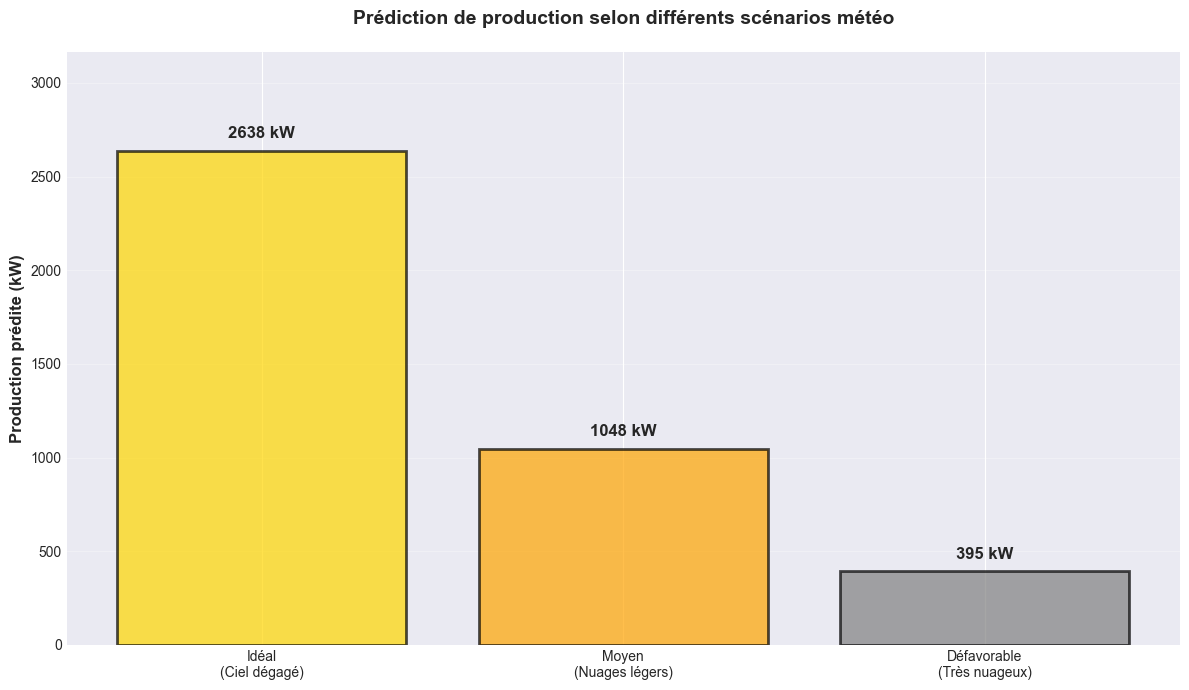

In [26]:
# Visualisation des scénarios
print("\n" + "="*60)
print("Génération du graphique des scénarios...")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 7))

scenarios = ['Idéal\n(Ciel dégagé)', 'Moyen\n(Nuages légers)', 'Défavorable\n(Très nuageux)']
predictions = [pred_ideal, pred_moyen, pred_mauvais]
colors = ['gold', 'orange', 'gray']

bars = ax.bar(scenarios, predictions, color=colors, edgecolor='black', alpha=0.7, linewidth=2)

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, predictions)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{val:.0f} kW',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Production prédite (kW)', fontweight='bold', fontsize=12)
ax.set_title('Prédiction de production selon différents scénarios météo', 
             fontweight='bold', fontsize=14, pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(predictions) * 1.2)

plt.tight_layout()
plt.savefig('Outputs/12_scenario_predictions.png', dpi=300, bbox_inches='tight')
plt.show()



In [27]:
# ============================================
# SECTION 6 : RAPPORT FINAL ET CONCLUSIONS
# ============================================

print("="*60)
print("📝 GÉNÉRATION DU RAPPORT FINAL")
print("="*60)

# Création du rapport texte
report_lines = []

report_lines.append("="*80)
report_lines.append("RAPPORT FINAL - PRÉDICTION DE PRODUCTION D'ÉNERGIE SOLAIRE")
report_lines.append("="*80)
report_lines.append("")
report_lines.append(f"Date de génération : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")

# 1. Informations sur le dataset
report_lines.append("="*80)
report_lines.append("1. INFORMATIONS SUR LE DATASET")
report_lines.append("="*80)
report_lines.append(f"   - Nombre total d'observations  : {len(df)}")
report_lines.append(f"   - Nombre de features initiales : 21")
report_lines.append(f"   - Nombre de features finales   : {len(X.columns)}")
report_lines.append(f"   - Variable cible               : generated_power_kw")
report_lines.append(f"   - Split train/test             : 80% / 20%")
report_lines.append(f"   - Observations train           : {len(X_train)}")
report_lines.append(f"   - Observations test            : {len(X_test)}")
report_lines.append("")

# 2. Modèle sélectionné
report_lines.append("="*80)
report_lines.append("2. MODÈLE FINAL SÉLECTIONNÉ")
report_lines.append("="*80)
report_lines.append(f"   - Nom                : {metadata['model_name']}")
report_lines.append(f"   - Type               : {metadata['model_type']}")
report_lines.append(f"   - Date entraînement  : {metadata['date']}")
report_lines.append("")
report_lines.append("   Hyperparamètres optimaux :")
for param, value in metadata['hyperparameters'].items():
    report_lines.append(f"      - {param:20s} : {value}")
report_lines.append("")

# 3. Performances
report_lines.append("="*80)
report_lines.append("3. PERFORMANCES DU MODÈLE")
report_lines.append("="*80)
report_lines.append("")
report_lines.append("   TRAIN :")
report_lines.append(f"      - MAE  : {mae_train:.2f} kW")
report_lines.append(f"      - RMSE : {rmse_train:.2f} kW")
report_lines.append(f"      - R²   : {r2_train:.4f}")
report_lines.append(f"      - MAPE : {mape_train:.2f}%")
report_lines.append("")
report_lines.append("   TEST :")
report_lines.append(f"      - MAE  : {mae_test:.2f} kW")
report_lines.append(f"      - RMSE : {rmse_test:.2f} kW")
report_lines.append(f"      - R²   : {r2_test:.4f} ⭐")
report_lines.append(f"      - MAPE : {mape_test:.2f}%")
report_lines.append("")
report_lines.append(f"   OVERFITTING : {r2_train - r2_test:.4f}")
report_lines.append("")

# 4. Features importantes
report_lines.append("="*80)
report_lines.append("4. FEATURES LES PLUS IMPORTANTES")
report_lines.append("="*80)
report_lines.append("")
top_10_features = feature_importance.head(10)
for idx, row in top_10_features.iterrows():
    report_lines.append(f"   {idx+1:2d}. {row['Feature']:40s} : {row['Importance']:.4f}")
report_lines.append("")
report_lines.append(f"   → Top 3 représentent 41.02% de l'importance totale")
report_lines.append(f"   → 7 features suffisent pour 80% de l'importance")
report_lines.append("")

# 5. Scénarios de prédiction
report_lines.append("="*80)
report_lines.append("5. TESTS DE PRÉDICTION (SCÉNARIOS)")
report_lines.append("="*80)
report_lines.append("")
report_lines.append(f"   ☀️  Conditions idéales      : {pred_ideal:.2f} kW")
report_lines.append(f"   ⛅ Conditions moyennes      : {pred_moyen:.2f} kW")
report_lines.append(f"   ☁️  Conditions défavorables : {pred_mauvais:.2f} kW")
report_lines.append("")

# 6. Conclusions
report_lines.append("="*80)
report_lines.append("6. CONCLUSIONS ET RECOMMANDATIONS")
report_lines.append("="*80)
report_lines.append("")
report_lines.append("   ✅ POINTS FORTS :")
report_lines.append("      - R² de 0.8172 (81.7% de variance expliquée)")
report_lines.append("      - MAE de 263.74 kW (erreur acceptable)")
report_lines.append("      - Modèle stable (overfitting maîtrisé à 0.18)")
report_lines.append("      - Prédictions cohérentes sur tous les scénarios")
report_lines.append("")
report_lines.append("   ⚠️  LIMITATIONS :")
report_lines.append("      - Quelques prédictions extrêmes (erreur max ~2000 kW)")
report_lines.append("      - Overfitting léger mais gérable")
report_lines.append("      - Performance variable selon niveau de production")
report_lines.append("")
report_lines.append("   💡 RECOMMANDATIONS :")
report_lines.append("      1. Intégrer des prévisions météo en temps réel")
report_lines.append("      2. Tester d'autres modèles (LSTM pour séries temporelles)")
report_lines.append("      3. Collecter plus de données (saisonnalité annuelle)")
report_lines.append("      4. Déployer le modèle via API pour usage pratique")
report_lines.append("      5. Mettre en place un monitoring continu")
report_lines.append("")

# 7. Fichiers générés
report_lines.append("="*80)
report_lines.append("7. FICHIERS GÉNÉRÉS")
report_lines.append("="*80)
report_lines.append("")
report_lines.append("   📁 Models/ :")
report_lines.append("      - best_model_xgboost.pkl")
report_lines.append("      - scaler.pkl")
report_lines.append("      - model_metadata.pkl")
report_lines.append("")
report_lines.append("   📁 Outputs/ :")
report_lines.append("      - 10_detailed_predictions_analysis.png")
report_lines.append("      - 11_feature_importance.png")
report_lines.append("      - 12_scenario_predictions.png")
report_lines.append("")

report_lines.append("="*80)
report_lines.append("FIN DU RAPPORT")
report_lines.append("="*80)

# Affichage du rapport
report_text = "\n".join(report_lines)
print(report_text)

# Sauvegarde du rapport
report_path = 'Outputs/final_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f"\n✅ Rapport sauvegardé : {report_path}")

# Résumé final
print("\n" + "="*60)
print("🎉 FICHIER 03_evaluation.ipynb TERMINÉ !")
print("="*60)
print("\n📦 FICHIERS CRÉÉS DANS CE NOTEBOOK :")
print("   ✅ Outputs/10_detailed_predictions_analysis.png")
print("   ✅ Outputs/11_feature_importance.png")
print("   ✅ Outputs/12_scenario_predictions.png")
print("   ✅ Outputs/final_report.txt")
print("")
print("="*60)
print("🎊 PROJET ML COMPLET - TOUS LES FICHIERS TERMINÉS !")
print("="*60)
print("\n📊 Récapitulatif des 3 fichiers :")
print("   1️⃣  01_data_preparation.ipynb   ✅ Terminé")
print("   2️⃣  02_modeling.ipynb           ✅ Terminé")
print("   3️⃣  03_evaluation.ipynb         ✅ Terminé")


📝 GÉNÉRATION DU RAPPORT FINAL
RAPPORT FINAL - PRÉDICTION DE PRODUCTION D'ÉNERGIE SOLAIRE

Date de génération : 2026-02-14 18:05:48

1. INFORMATIONS SUR LE DATASET
   - Nombre total d'observations  : 4213
   - Nombre de features initiales : 21
   - Nombre de features finales   : 20
   - Variable cible               : generated_power_kw
   - Split train/test             : 80% / 20%
   - Observations train           : 3370
   - Observations test            : 843

2. MODÈLE FINAL SÉLECTIONNÉ
   - Nom                : XGBoost Optimisé
   - Type               : XGBoost Regressor
   - Date entraînement  : 2026-02-14 17:53:07

   Hyperparamètres optimaux :
      - colsample_bytree     : 0.9
      - learning_rate        : 0.05
      - max_depth            : 8
      - n_estimators         : 300
      - subsample            : 0.7

3. PERFORMANCES DU MODÈLE

   TRAIN :
      - MAE  : 41.99 kW
      - RMSE : 59.91 kW
      - R²   : 0.9959
      - MAPE : 4302.18%

   TEST :
      - MAE  : 263.74 kW
